# Setup Inicial

## Importando Bibliotecas

In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
from google.cloud import bigquery
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Autenticando o Client do BigQuery

In [2]:
warnings.filterwarnings('ignore')
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = './bigquery_api_key.json'
client = bigquery.Client()

# Questão 2 — Análise de Funil e Segmentação de Usuários

## 2.1 — Análise de Funil

### Mapeie o funil de conversão do e-commerce com base nos eventos disponíveis no dataset

A partir da coluna `hits.eCommerceAction.action_type`, podemos obter diversas intereções que usuário fez com o produto durante a sessão. Neste caso, utilizaremos as seguintes:
- product detail view
- add to cart
- checkout

Podemos combinar isso com as duas outras métricas que utilizamos na última questão, a de visitas e a de transações. Com isso, podemos construir o seguinte funil:

Visita -> Visualização de produto -> Adição ao carrinho -> Checkout -> Compra

### Calcule a taxa de abandono em cada etapa do funil

In [3]:
# Mapeia as etapas da compra em flags (0 ou 1) por sessão e agrupa os totais.
# Calcula a taxa de abandono percentual de cada etapa em relação ao volume total da etapa anterior.
query_1 = """
WITH funnel_stages AS (
  SELECT
    '1. Total Sessions' AS step_name,
    COUNT(DISTINCT visitId) AS count_sessions,
    1 AS step_order
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
  
  UNION ALL
  
  SELECT
    '2. Product View' AS step_name,
    COUNT(DISTINCT visitId) AS count_sessions,
    2 AS step_order
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`, UNNEST(hits) AS hits
  WHERE hits.eCommerceAction.action_type = '2'
  
  UNION ALL
  
  SELECT
    '3. Add to Cart' AS step_name,
    COUNT(DISTINCT visitId) AS count_sessions,
    3 AS step_order
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`, UNNEST(hits) AS hits
  WHERE hits.eCommerceAction.action_type = '3'
  
  UNION ALL
  
  SELECT
    '4. Checkout' AS step_name,
    COUNT(DISTINCT visitId) AS count_sessions,
    4 AS step_order
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`, UNNEST(hits) AS hits
  WHERE hits.eCommerceAction.action_type = '5'
  
  UNION ALL
  
  SELECT
    '5. Transaction' AS step_name,
    COUNT(DISTINCT visitId) AS count_sessions,
    5 AS step_order
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
  WHERE totals.transactions >= 1
)

SELECT 
  step_name,
  count_sessions,
  ROUND(100 * Safe_Divide(count_sessions, LAG(count_sessions) OVER (ORDER BY step_order)), 2) AS retention_rate,
  ROUND(100 * (1 - Safe_Divide(count_sessions, LAG(count_sessions) OVER (ORDER BY step_order))), 2) AS drop_off_rate
FROM funnel_stages
ORDER BY step_order
"""

funnel_df = client.query(query_1).to_dataframe()

display(funnel_df)

,step_name,count_sessions,retention_rate,drop_off_rate
0,1. Total Sessions,886303,NaN,NaN
1,2. Product View,123692,13.96,86.04
2,3. Add to Cart,50022,40.44,59.56
3,4. Checkout,22371,44.72,55.28
4,5. Transaction,11549,51.62,48.38


Observa-se uma queda massiva na entrada do funil, menos de 14% dos usuários que iniciam uma sessão permanecem após essa etapa. Por outro lado, após o checkout apenas metade não conclui a compra do produto.

### Existe diferença no comportamento do funil entre canais pagos (CPC) e orgânicos?

In [4]:
# Compara o funil de vendas entre tráfego pago (CPC) e orgânico (Organic Search).
# Calcula a taxa de abandono percentual de cada etapa em relação ao volume total da etapa anterior.
query_2 = """
WITH raw_data AS (
  SELECT
    visitId,
    trafficSource.medium,
    hits.eCommerceAction.action_type,
    IFNULL(totals.transactions, 0) AS transactions
  FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`,
  UNNEST(hits) AS hits
  WHERE trafficSource.medium IN ('cpc', 'organic')
),

funnel_stages AS (
  -- ETAPA 1: Total de Sessões
  SELECT '1. Total Sessions' AS step_name, medium, COUNT(DISTINCT visitId) AS count_sessions, 1 AS step_order
  FROM raw_data GROUP BY medium
  
  UNION ALL
  -- ETAPA 2: Product View
  SELECT '2. Product View', medium, COUNT(DISTINCT visitId), 2
  FROM raw_data WHERE action_type = '2' GROUP BY medium
  
  UNION ALL
  -- ETAPA 3: Add to Cart
  SELECT '3. Add to Cart', medium, COUNT(DISTINCT visitId), 3
  FROM raw_data WHERE action_type = '3' GROUP BY medium
  
  UNION ALL
  -- ETAPA 4: Checkout
  SELECT '4. Checkout', medium, COUNT(DISTINCT visitId), 4
  FROM raw_data WHERE action_type = '5' GROUP BY medium
  
  UNION ALL
  -- ETAPA 5: Transaction
  SELECT '5. Transaction', medium, COUNT(DISTINCT visitId), 5
  FROM raw_data WHERE transactions >= 1 GROUP BY medium
)

SELECT 
  medium AS channel,
  step_name,
  count_sessions,
  -- O PARTITION BY medium garante que o cálculo não misture dados de canais diferentes
  ROUND(100 * Safe_Divide(count_sessions, LAG(count_sessions) OVER (PARTITION BY medium ORDER BY step_order)), 2) AS retention_rate,
  ROUND(100 * (1 - Safe_Divide(count_sessions, LAG(count_sessions) OVER (PARTITION BY medium ORDER BY step_order))), 2) AS drop_off_rate
FROM funnel_stages
ORDER BY channel, step_order
"""

df_cpc_vs_organic = client.query(query_2).to_dataframe()
display(df_cpc_vs_organic)

,channel,step_name,count_sessions,retention_rate,drop_off_rate
0,cpc,1. Total Sessions,13037,NaN,NaN
1,cpc,2. Product View,2847,21.84,78.16
2,cpc,3. Add to Cart,1047,36.78,63.22
3,cpc,4. Checkout,406,38.78,61.22
4,cpc,5. Transaction,243,59.85,40.15
5,organic,1. Total Sessions,232048,NaN,NaN
6,organic,2. Product View,38269,16.49,83.51
7,organic,3. Add to Cart,13873,36.25,63.75
8,organic,4. Checkout,4927,35.52,64.48
9,organic,5. Transaction,2126,43.15,56.85


Ao comparamos os fois funis, é possível observar que o tráfego pago (CPC) apresenta uma eficiência superior em todas as etapas do funil quando comparado ao Orgânico, com destaque para a conversão final (59,8% vs 43,1%). Contudo, o problema do abandono inicial, continua alto como observamos na primeira tabela.

### Apresente os resultados de forma visual e explique o que cada queda no funil representa em termos de receita potencial perdida

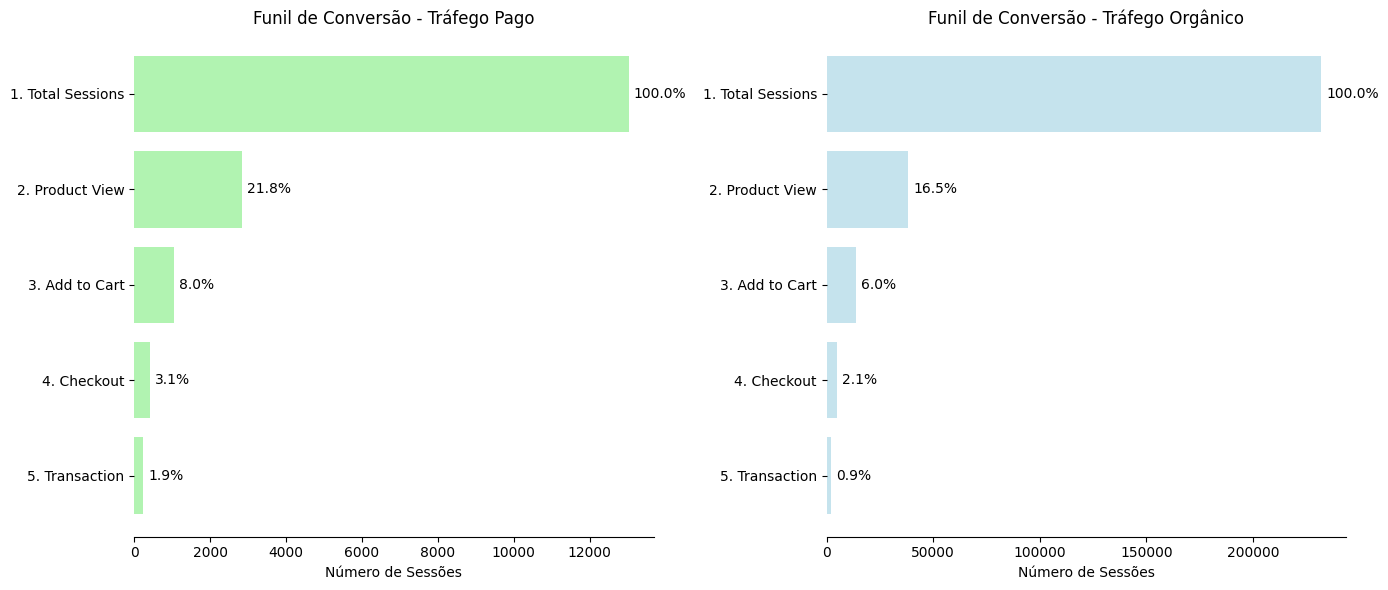

In [5]:
df_cpc = df_cpc_vs_organic[df_cpc_vs_organic['channel'] == 'cpc'].copy()
df_organic = df_cpc_vs_organic[df_cpc_vs_organic['channel'] == 'organic'].copy()

def plot_funnel_ax(ax, df, channel_name, color):
    steps = df['step_name'].tolist()
    counts = df['count_sessions'].tolist()
    total = counts[0]
    pct = [(c / total) * 100 if total != 0 else 0 for c in counts]

    y_pos = range(len(steps))
    ax.barh(y_pos, counts, color=color, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(steps)
    ax.set_xlabel('Número de Sessões')
    ax.set_title(f'Funil de Conversão - {channel_name}')
    ax.invert_yaxis()
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    for i, (count, p) in enumerate(zip(counts, pct)):
        label = f'{p:.1f}%'
        ax.text(count + max(counts)*0.01, i, label, va='center')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

plot_funnel_ax(ax1, df_cpc, 'Tráfego Pago', color='lightgreen')
plot_funnel_ax(ax2, df_organic, 'Tráfego Orgânico', color='lightblue')

plt.tight_layout()
plt.show()

As quedas no funil do tráfego orgânico evidenciam uma perda massiva de receita potencial por volume: embora atraia quase 20 vezes mais sessões que o pago, a conversão final é menos da metade (0,9% vs 1,9%). Isso indica que o tráfego orgânico retém menos intenção comercial, perdendo a maior parte do valor logo na transição de interesse (Sessão para Produto), onde 83,5% dos usuários abandonam o site sem sequer visualizar um item.

Em contraste, o tráfego pago demonstra maior eficiência financeira, apresentando taxas de retenção superiores em todas as etapas, especialmente no checkout. Enquanto o orgânico perde mais de 57% dos usuários que já estavam no checkout, o pago retém uma proporção maior de compradores decididos. O abandono nas fases finais de ambos os canais representa a receita mais grave de se perder, pois o custo de aquisição já foi investido e o usuário foi barrado por fricções técnicas ou financeiras no momento do fechamento.

## 2.2 — Segmentação de Usuários

### Defina os segmentos escolhidos e justifique a escolha

Para a segmentação, reunirei diversas estatísticas dos clientes e então aplicarei um modelo de clusterização para identificar os grupos de usuários dentro da base.

In [3]:
# Query que seleciona estatísticas dos usuários para serem usadas na clusterização
query_3 = """
SELECT
    fullVisitorId,

    COUNT(visitId) as sessions,

    SUM(totals.pageviews) as pageviews,

    SUM(totals.timeOnSite) as time_on_site,

    SAFE_DIVIDE(
        SUM(totals.pageviews),
        COUNT(visitId)
    ) as pages_per_session,

    COALESCE(SUM(totals.transactions), 0) as transactions,

    COALESCE(SUM(totals.totalTransactionRevenue/1000000), 0) as revenue

FROM `bigquery-public-data.google_analytics_sample.ga_sessions_*`
GROUP BY fullVisitorId
"""

visitor_stats_df = client.query(query_3).to_dataframe()

In [5]:
features = visitor_stats_df[[
    'sessions',
    'pageviews',
    'time_on_site',
    'transactions',
    'revenue'
]].fillna(0)

# Calcula o log(x + 1) de cada feature para lidar com outliers, e depois as padroniza
features = np.log1p(features)
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Utilizaremos o silhouette score para determinar o melhor número de clusters:
best_k = 0
best_score = -1

X_sample = X[np.random.choice(X.shape[0], 50000, replace=False)]

for k in range(3, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)

    score = silhouette_score(X_sample, labels)

    if score > best_score:
        best_score = score
        best_k = k

print(best_k, best_score)

6 0.6835930213046821


Pelo método da silhueta, o número ideal de clusters é seis. Vamos observar a média das variáveis para entendermos o perfil de cada cluster:

In [8]:
kmeans = KMeans(n_clusters=6, random_state=42)
visitor_stats_df['cluster'] = kmeans.fit_predict(X)
cluster_summary = (
    visitor_stats_df
    .drop(columns=['fullVisitorId'])
    .groupby('cluster')
    .mean(numeric_only=True)
    .reset_index()
)

display(cluster_summary)

,cluster,sessions,pageviews,time_on_site,pages_per_session,transactions,revenue
0,0,1.049227,1.08358,4.035489,1.034087,0.0,0.000000
1,1,1.329369,12.573152,498.983973,10.443306,0.000069,0.000000
2,2,4.666714,23.298905,1076.21868,5.161041,0.000394,0.000000
3,3,9.381351,124.649731,4779.028093,17.716905,2.180514,658.875965
4,4,1.045954,3.014893,92.805643,2.937607,0.0,0.000000
5,5,2.453247,38.558276,1444.847077,19.666590,1.014164,81.364751


Para a segmentação de usuários, utilizaremos quatro perfis:

- **Perfil 1:** Clusters 0 e 4
- **Perfil 2:** Clusters 1 e 2
- **Perfil 3:** Cluster 3
- **Perfil 4:** Cluster 5

As características de cada grupo serão melhor discutidas na próxima sessão.

### Descreva o perfil de cada segmento com métricas objetivas

**Perfil 1 - Baixo Engajamento:** apresenta métricas próximas de zero em todas as dimensões analisadas. Com apenas 1 página por sessão e tempo de permanência extremamente baixo, esses grupos não geram transações nem receita, representando um volume de tráfego que não interage com o conteúdo do site.

**Perfil 2 - Pesquisador Indeciso** registra um tempo de permanência alto, chegando a 1076 unidades no Cluster 2, acompanhado de uma média de 5 a 10 páginas por sessão. Apesar desse volume de interações e do tempo investido na plataforma, a conversão é inexistente ou residual. Esse perfil gasta um tempo considerável navegando e analisando diversas páginas o que demonstra que existe um interesse do usuário, mas ainda está travado na fase de consideração e não avança para o carrinho.

**Perfil 3 - Clientes de Alto Valor:** destaca-se como o grupo mais rentável e mais engajado com o conteúdo, concentrando os maiores índices de transações e receita da base. Esse desempenho financeiro está atrelado a um tempo de permanência e a uma profundidade de navegação muito superiores aos demais, confirmando que este é o público que mais consome e gera valor direto.

**Perfil 4 - Clientes Recorrentes:** demonstra constância, com um número elevado de sessões e muitas páginas visualizadas por acesso. Embora mantenha um volume de transações estável, a receita gerada é baixa quando comparada ao perfil de alta conversão, indicando um padrão de compras frequentes, porém de menor valor financeiro.

### Para qual segmento você priorizaria investimento em mídia paga? Por quê?

Eu escolheria o **Perfil 2 - Pesquisador Indeciso**. Como os dados indicam, são possíveis clientes que são engajados com o site com alto tempo de permanência e profundidade de navegação mas que não são convertidos em receita. Eles são o grupo que exigiria menos esforço para aumentar a receita e poderiam facilmente se tornar clientes de Alto Valor devido ao seu padrão de engajamento.

## 2.3 — Estratégia de Coleta de Dados

### Quais 3 dados que hoje não estão disponíveis seriam mais valiosos para melhorar a personalização de campanhas?

- **Dados de Pós-venda:** Informações sobre o pós-venda para avaliar se a satisfação do cliente é diferente entre os provenientes de tráfego pago e os que vieram de forma orgânica. Esses dados poderiam ser por exemplo: avaliação do produto e pedidos de reembolso.

- **Dados de Geolocalização:** A localização geográfica do possível cliente afeta diretamente o tempo de frete de um produto, e em empresas que vendem internacionalmente pode afetar o valor do imposto de importação. Tendo esse dado, a empresa poderia considerar mudanças logísticas, caso muitos clientes que vivem longe do centro de distribuição desistam da compra ao calcular a estimativa de entrega.

- **Preços da Concorrência:** O preço de produtos similares, ou até iguais, em outros sites é uma informação valiosa para determinarmos possíveis motivos para a não conversão. Clientes do **Perfil 2**, como gostam de pesquisar bastante antes da compra, podem desistir de comprar em nosso site por terem encontrado o mesmo produto em outro lugar por um preço melhor.

### Como você coletaria essas informações de forma ética e escalável?

- **Dados de Pós-venda:** Caso o site já tenha uma base de dados de vendas, basta adicionar uma coluna com o sessionId do usuário para acompanharmos o desfecho da venda.

- **Dados de Geolocalização:** Essa informação pode ser facilmente coletada através de cookies, ou pelo próprio navegador. Desde que o usuário aceite compartilhar sua localização conosco. Ou, com uma menor precisão, podemos simplesmente usar o endereço IP do usuário para termos uma noção aproximada da sua localização.

- **Preços da Concorrência:** A melhor forma de se fazer isso com escalabilidade é por meio de webscrapping, poderiamos guardar links para produtos similares de concorrentes, e, periódicamente, atualizar esses valores. 